Time column is increasing: True
Missing values:
time    0
0_x     0
dtype: int64


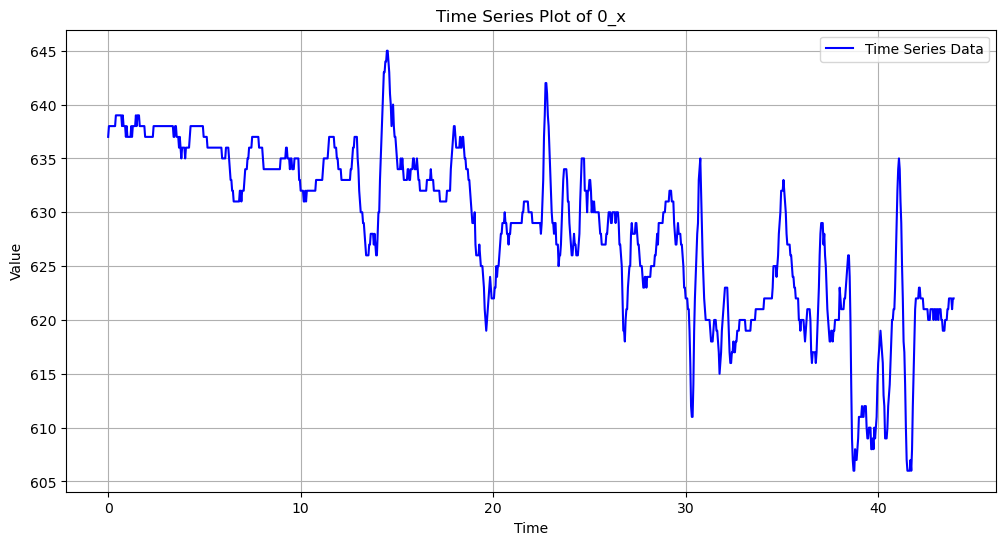

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df['time'].is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of 0_x")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# 4. ADF Durağanlık Testi
#adf_test = adfuller(df['0_x'])
#print("ADF Statistic:", adf_test[0])
#print("p-value:", adf_test[1])
#print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
#if adf_test[1] < 0.05:
    #print("Sonuç: Seri durağandır (Stationary)")
#else:
    #print("Sonuç: Seri durağan değildir (Non-Stationary)")

ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}
Sonuç: Seri durağan değildir (Non-Stationary)


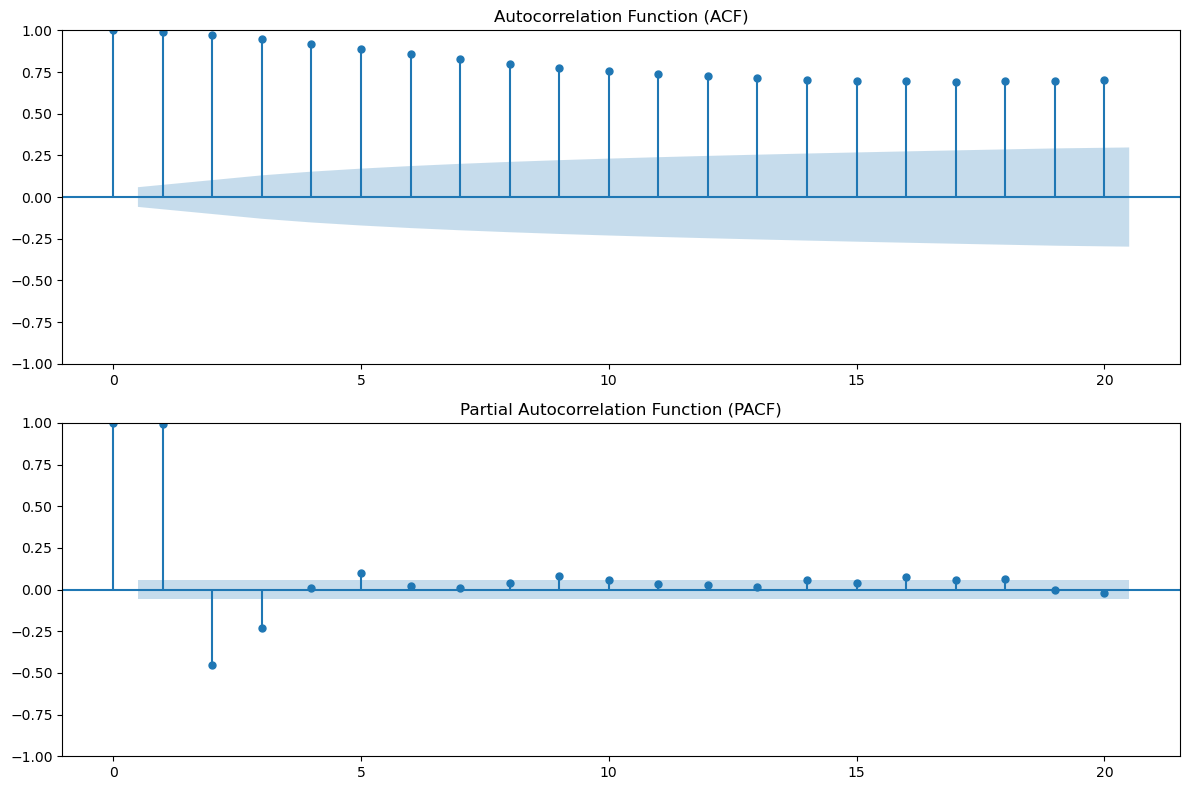

In [9]:
# 5. ACF ve PACF Grafikleri
##fig, ax = plt.subplots(2, 1, figsize=(12, 8))
#plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
#ax[0].set_title("Autocorrelation Function (ACF)")
#plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
#ax[1].set_title("Partial Autocorrelation Function (PACF)")
#plt.tight_layout()
#plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1099
Model:               SARIMAX(2, 1, 3)   Log Likelihood               -1391.095
Date:                Tue, 18 Mar 2025   AIC                           2794.190
Time:                        23:33:59   BIC                           2824.198
Sample:                             0   HQIC                          2805.543
                               - 1099                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6269      0.038     42.383      0.000       1.552       1.702
ar.L2         -0.6767      0.038    -18.012      0.000      -0.750      -0.603
ma.L1         -1.2949      0.043    -30.211      0.0

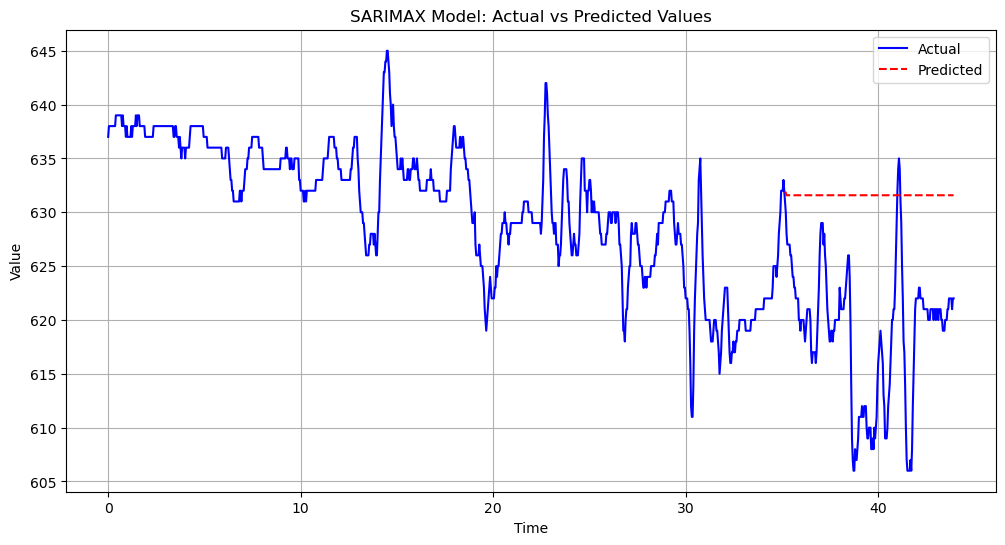

In [12]:
# 8. pmdarima ile En Uygun SARIMAX Modelini Seçme
auto_sarimax_model = pm.auto_arima(df['0_x'], seasonal=False, exogenous=None, stepwise=True, suppress_warnings=True)
print(auto_sarimax_model.summary())

# 9. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]

# 10. Modeli Sadece Train Verisinde Eğitme
auto_sarimax_model = pm.auto_arima(train, seasonal=False, exogenous=None, stepwise=True, suppress_warnings=True)
predictions = auto_sarimax_model.predict(n_periods=len(test))
predictions = pd.Series(predictions, index=test.index)  # Dizini test ile eşleştiriyoruz

# 11. Tahminlerin Görselleştirilmesi
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Actual", color="blue")
plt.plot(df['time'][train_size:], predictions, label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("SARIMAX Model: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 12. Performans Metriklerini Hesaplama
actual_values = test.values
predicted_values = predictions.values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for actual, predicted in zip(actual_values, predicted_values):
    print(f"Gerçek: {actual}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.9320526295511
Gerçek: 630, Tahmin: 631.8032350742652
Gerçek: 628, Tahmin: 631.5791535632806
Gerçek: 627, Tahmin: 631.5791535632806
Gerçek: 627, Tahmin: 631.5791535632806
Gerçek: 627, Tahmin: 631.5791535632806
Gerçek: 627, Tahmin: 631.5791535632806
Gerçek: 626, Tahmin: 631.5791535632806
Gerçek: 626, Tahmin: 631.5791535632806
Gerçek: 625, Tahmin: 631.5791535632806
Gerçek: 624, Tahmin: 631.5791535632806
Gerçek: 624, Tahmin: 631.5791535632806
Gerçek: 623, Tahmin: 631.5791535632806
Gerçek: 623, Tahmin: 631.5791535632806
Gerçek: 622, Tahmin: 631.5791535632806
Gerçek: 622, Tahmin: 631.5791535632806
Gerçek: 622, Tahmin: 631.5791535632806
Gerçek: 622, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 631.5791535632806
Gerçek: 619, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 631.5791535632806
Gerçek: 620, Tahmin: 